# Notebook 13: AMSR2 Spatial and Temporal Comparison (v6)

**Created:** 30 March 2026 | **Revised:** 31 March 2026
**Version 4 fixes:**
1. Ross Sea map extent — compute projection-native x/y bounds to handle dateline wrapping correctly
2. Colourmap changed from YlGnBu (contains blue/orange) to 'magma' (no blue/orange conflicts with sector labels)
3. All annotations report both mean and median values
4. Time series x-axis: first month of each winter season labelled with year (Aug 2022, May 2023, etc.)
5. PDF histogram: AMSR2 two-layer rendering for visibility


## 13.1 Setup

In [1]:
import sys, os, warnings, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import rcParams
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import pearsonr
warnings.filterwarnings('ignore')

sys.path.insert(0, '/g/data/gv90/xl1657/phd/M2_workspace/notebooks')

HS_DIR  = '/g/data/gv90/xl1657/phd/M2_workspace/output/snow_thickness'
FIG_DIR = '/g/data/gv90/xl1657/phd/M2_workspace/output/figures'
os.makedirs(FIG_DIR, exist_ok=True)

rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6.5,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.4,
    'ytick.major.width': 0.4,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'lines.linewidth': 0.8,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
    'pdf.fonttype': 42,
    'figure.dpi': 150,
})

C_WEDDELL = '#0072B2'
C_ROSS    = '#D55E00'
C_AMSR2   = '#444444'

try:
    from pyresample import create_area_def
    from pyresample.bucket import BucketResampler
    print('pyresample available')
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                           '--user', '--break-system-packages', 'pyresample'])
    from pyresample import create_area_def
    from pyresample.bucket import BucketResampler

import dask.array as da

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    print('cartopy available')
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                           '--user', '--break-system-packages', 'cartopy'])
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

print('Setup complete')


pyresample available
cartopy available
Setup complete


## 13.2 Load Data and Apply δ = 0.70

In [2]:
CACHE = f'{HS_DIR}/snow_thickness_with_amsr2_all.csv'
df = pd.read_csv(CACHE)
print(f'Loaded {len(df):,} matchups')

df['year']  = df['year_month'] // 100
df['month'] = df['year_month'] % 100
df['delta_f'] = df['is2_fb_wm'] - df['cs2_rfb']

delta_baseline = 0.70
rho_s = 330.0
eta_s = (1.0 + 0.51 * (rho_s / 1000.0)) ** 1.5
df['snow_thickness'] = df['delta_f'] / (delta_baseline * eta_s)
print(f'Applied delta = {delta_baseline}, eta_s = {eta_s:.4f}')

def assign_sector(lon):
    if -62 <= lon <= 15:
        return 'Weddell'
    elif (160 <= lon <= 180) or (-180 <= lon <= -140):
        return 'Ross'
    else:
        return 'Other'

df['sector']    = df['lon'].apply(assign_sector)
df['is_winter'] = df['month'].isin([5, 6, 7, 8, 9, 10])

mask = (df['is_winter'] &
        df['sector'].isin(['Weddell', 'Ross']) &
        (df['snow_thickness'] > 0) &
        (~df['AMSR2_snow_depth'].isna()) &
        (df['AMSR2_snow_depth'] > 0) &
        (df['AMSR2_snow_depth'] <= 1.5))
dc = df[mask].copy()
dc['bias'] = dc['snow_thickness'] - dc['AMSR2_snow_depth']

print(f'\nComparison subset: {len(dc):,} matchups')
for sec in ['Weddell', 'Ross']:
    sub = dc[dc.sector == sec]
    print(f'\n  {sec} (n = {len(sub):,}):')
    print(f'    C2I:   mean = {sub.snow_thickness.mean():.3f} m, median = {sub.snow_thickness.median():.3f} m')
    print(f'    AMSR2: mean = {sub.AMSR2_snow_depth.mean():.3f} m, median = {sub.AMSR2_snow_depth.median():.3f} m')
    print(f'    Diff:  mean = {sub.bias.mean():+.3f} m, median = {sub.bias.median():+.3f} m')


Loaded 126,283 matchups
Applied delta = 0.7, eta_s = 1.2628

Comparison subset: 72,860 matchups

  Weddell (n = 42,432):
    C2I:   mean = 0.255 m, median = 0.188 m
    AMSR2: mean = 0.310 m, median = 0.210 m
    Diff:  mean = -0.055 m, median = -0.047 m

  Ross (n = 30,428):
    C2I:   mean = 0.217 m, median = 0.156 m
    AMSR2: mean = 0.277 m, median = 0.180 m
    Diff:  mean = -0.060 m, median = -0.034 m


## 13.3 Grid onto 25 km Polar Stereographic

In [3]:
RESOLUTION = 25000
area_def = create_area_def(
    'south_polar_25km',
    {'proj': 'stere', 'lat_0': -90, 'lon_0': 0, 'lat_ts': -70,
     'a': 6378137, 'b': 6356752.3142},
    area_extent=(-3950000, -3950000, 3950000, 3950000),
    resolution=RESOLUTION,
)
ny, nx = area_def.shape
n_cells = ny * nx
half = RESOLUTION / 2.0
print(f'Grid: {ny} x {nx} = {n_cells:,} cells at {RESOLUTION/1000:.0f} km')

lons_da = da.from_array(dc['lon'].values.astype(np.float64), chunks=-1)
lats_da = da.from_array(dc['lat'].values.astype(np.float64), chunks=-1)
resampler = BucketResampler(area_def, lons_da, lats_da)

idxs = resampler.idxs
if hasattr(idxs, 'compute'):
    idxs = idxs.compute()

valid_mask = idxs >= 0
unique_bins = np.unique(idxs[valid_mask])
print(f'Grid cells with data: {len(unique_bins):,}')

c2i_vals  = dc['snow_thickness'].values
amsr_vals = dc['AMSR2_snow_depth'].values

grid_c2i_med   = np.full(n_cells, np.nan)
grid_amsr_med  = np.full(n_cells, np.nan)
grid_diff_med  = np.full(n_cells, np.nan)
grid_count     = np.zeros(n_cells, dtype=int)

for b in unique_bins:
    pts_mask = idxs == b
    c2i_pts  = c2i_vals[pts_mask]
    amsr_pts = amsr_vals[pts_mask]
    grid_c2i_med[b]  = np.nanmean(c2i_pts)
    grid_amsr_med[b] = np.nanmean(amsr_pts)
    grid_diff_med[b] = np.nanmean(c2i_pts) - np.nanmean(amsr_pts)
    grid_count[b]    = len(c2i_pts)

grid_c2i_med  = grid_c2i_med.reshape((ny, nx))
grid_amsr_med = grid_amsr_med.reshape((ny, nx))
grid_diff_med = grid_diff_med.reshape((ny, nx))
grid_count    = grid_count.reshape((ny, nx))

filled = grid_count > 0

x_centres = np.linspace(area_def.area_extent[0] + half,
                        area_def.area_extent[2] - half, nx)
y_centres = np.linspace(area_def.area_extent[3] - half,
                        area_def.area_extent[1] + half, ny)
xx, yy = np.meshgrid(x_centres, y_centres)

lons_grid, lats_grid = area_def.get_lonlats()

print(f'\nFilled cells: {filled.sum():,}')

for sec_name, sec_func in [
    ('Weddell',       lambda lo: (-62 <= lo) & (lo <= 15)),
    ('Weddell_West',  lambda lo: (-62 <= lo) & (lo < -45)),
    ('Weddell_East',  lambda lo: (-45 <= lo) & (lo <= 15)),
    ('Ross',          lambda lo: ((160 <= lo) & (lo <= 180)) | ((-180 <= lo) & (lo <= -140))),
]:
    sec_mask = filled & sec_func(lons_grid)
    n_sec = sec_mask.sum()
    if n_sec > 0:
        diffs = grid_diff_med[sec_mask]
        print(f'\n{sec_name} ({n_sec:,} cells):')
        print(f'  Mean diff: {np.nanmean(diffs):+.3f} m')
        print(f'  AMSR2 > C2I: {100*np.sum(diffs < 0)/n_sec:.0f}%, C2I > AMSR2: {100*np.sum(diffs > 0)/n_sec:.0f}%')


Grid: 316 x 316 = 99,856 cells at 25 km
Grid cells with data: 3,650

Filled cells: 3,650

Weddell (2,064 cells):
  Mean diff: -0.018 m
  AMSR2 > C2I: 46%, C2I > AMSR2: 54%

Weddell_West (457 cells):
  Mean diff: -0.129 m
  AMSR2 > C2I: 64%, C2I > AMSR2: 36%

Weddell_East (1,607 cells):
  Mean diff: +0.013 m
  AMSR2 > C2I: 40%, C2I > AMSR2: 60%

Ross (1,584 cells):
  Mean diff: -0.021 m
  AMSR2 > C2I: 42%, C2I > AMSR2: 58%


## 13.4 Figure 9: 6-Panel Sector Maps

Fixed: Ross extent uses projection-native x/y coordinates to handle dateline correctly. Colourmap changed to 'magma' (no blue/orange conflicts).

Weddell proj extent: x=[-3507347, 1370291], y=[538443, 3817176]
Ross proj extent:    x=[-2667504, 1624469], y=[-3696355, -921094]
Weddell y-range: 3279 km, Ross y-range: 2775 km
Height ratios: Weddell=0.67, Ross=0.65


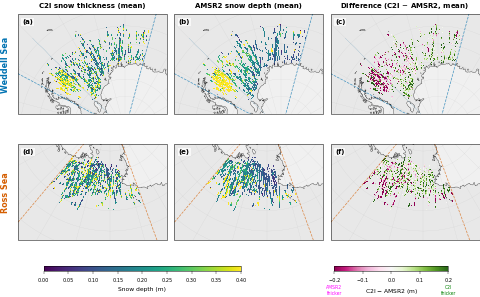

Figure 9 (6-panel, trimmed) saved


In [4]:
# ─── Compute sector extents in projection coordinates ────────────
proj_crs = ccrs.SouthPolarStereo()
pc = ccrs.PlateCarree()

def get_sector_proj_extent(proj, lons, lats, pad_x=75000, pad_y=50000):
    """Compute projection x/y limits with separate x/y padding."""
    pts = proj.transform_points(pc, np.array(lons), np.array(lats))
    return (pts[:, 0].min() - pad_x, pts[:, 0].max() + pad_x,
            pts[:, 1].min() - pad_y, pts[:, 1].max() + pad_y)

# Weddell: trace boundary — trim latitudes to data-relevant range
w_lons = np.array([-65, -45, -24, 0, 15, 20, 20, -65])
w_lats = np.array([-57, -57, -57, -57, -57, -57, -78, -78])
w_xmin, w_xmax, w_ymin, w_ymax = get_sector_proj_extent(
    proj_crs, w_lons, w_lats, pad_x=75000, pad_y=30000)

# Ross: trace boundary — tighter lat range to eliminate polar gap
r_lons = np.array([155, 160, 170, 180, -170, -160, -150, -140, -135,
                   -135, 155])
r_lats = np.array([-58, -58, -58, -58, -58, -58, -58, -58, -58,
                   -78, -78])
r_xmin, r_xmax, r_ymin, r_ymax = get_sector_proj_extent(
    proj_crs, r_lons, r_lats, pad_x=75000, pad_y=30000)

print(f'Weddell proj extent: x=[{w_xmin:.0f}, {w_xmax:.0f}], y=[{w_ymin:.0f}, {w_ymax:.0f}]')
print(f'Ross proj extent:    x=[{r_xmin:.0f}, {r_xmax:.0f}], y=[{r_ymin:.0f}, {r_ymax:.0f}]')

# Compute natural aspect ratios for height_ratios
w_aspect = (w_ymax - w_ymin) / (w_xmax - w_xmin)
r_aspect = (r_ymax - r_ymin) / (r_xmax - r_xmin)
print(f'Weddell y-range: {(w_ymax-w_ymin)/1e3:.0f} km, '
      f'Ross y-range: {(r_ymax-r_ymin)/1e3:.0f} km')
print(f'Height ratios: Weddell={w_aspect:.2f}, Ross={r_aspect:.2f}')

# ─── Colourmaps ──────────────────────────────────────────────────
cmap_snow = 'viridis'
vmin_snow, vmax_snow = 0, 0.40
cmap_diff = 'PiYG'
vmax_diff = 0.20
norm_diff = TwoSlopeNorm(vmin=-vmax_diff, vcenter=0, vmax=vmax_diff)

# ─── Data arrays for each column ─────────────────────────────────
data_layers = []
for col_idx in range(3):
    if col_idx == 0:
        d = grid_c2i_med.copy()
    elif col_idx == 1:
        d = grid_amsr_med.copy()
    else:
        d = grid_diff_med.copy()
    d[~filled] = np.nan
    data_layers.append(d)

# ─── Sector configurations ───────────────────────────────────────
sector_cfg = [
    {'name': 'Weddell Sea', 'color': C_WEDDELL,
     'proj_extent': (w_xmin, w_xmax, w_ymin, w_ymax),
     'lon_bounds': [-62, 15], 'subsector': -45},
    {'name': 'Ross Sea', 'color': C_ROSS,
     'proj_extent': (r_xmin, r_xmax, r_ymin, r_ymax),
     'lon_bounds': [160, -140], 'subsector': None},
]

col_titles = ['C2I snow thickness (mean)', 'AMSR2 snow depth (mean)',
              r'Difference (C2I $-$ AMSR2, mean)']

# ─── Build 2×3 figure with proportional row heights ──────────────
fig, axes = plt.subplots(
    2, 3, figsize=(183/25.4, 105/25.4),
    subplot_kw={'projection': proj_crs},
    gridspec_kw={'height_ratios': [w_aspect, r_aspect]})
fig.subplots_adjust(wspace=0.05, hspace=0.08,
                    top=0.93, bottom=0.10, left=0.08, right=0.97)

for row_idx, cfg in enumerate(sector_cfg):
    xmin, xmax, ymin, ymax = cfg['proj_extent']

    for col_idx in range(3):
        ax = axes[row_idx, col_idx]
        plot_data = data_layers[col_idx]

        ax.set_facecolor('#e8e8e8')
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)

        ax.coastlines(resolution='50m', linewidth=0.3, color='black')
        ax.add_feature(cfeature.LAND, facecolor='#f0f0f0', edgecolor='none')
        ax.gridlines(crs=pc, draw_labels=False,
                     linewidth=0.15, color='grey', alpha=0.3,
                     xlocs=np.arange(-180, 180, 15),
                     ylocs=np.arange(-80, -50, 5))

        if col_idx < 2:
            pcm = ax.pcolormesh(xx, yy, plot_data,
                                cmap=cmap_snow,
                                vmin=vmin_snow, vmax=vmax_snow,
                                transform=proj_crs,
                                shading='nearest', rasterized=True)
        else:
            pcm = ax.pcolormesh(xx, yy, plot_data,
                                cmap=cmap_diff, norm=norm_diff,
                                transform=proj_crs,
                                shading='nearest', rasterized=True)

        # ── Sector boundary lines ────────────────────────────────
        for lon_val in cfg['lon_bounds']:
            lats_l = np.linspace(-90, -53, 150)
            lons_l = np.full_like(lats_l, lon_val)
            ax.plot(lons_l, lats_l, transform=pc,
                    color=cfg['color'], ls='--', lw=0.7, alpha=0.7)

        if cfg['subsector'] is not None:
            lats_l = np.linspace(-90, -53, 150)
            lons_l = np.full_like(lats_l, cfg['subsector'])
            ax.plot(lons_l, lats_l, transform=pc,
                    color=cfg['color'], ls=':', lw=0.5, alpha=0.5)

        if row_idx == 0:
            ax.set_title(col_titles[col_idx], fontsize=7,
                         fontweight='bold')

        if col_idx == 0:
            ax.text(-0.08, 0.5, cfg['name'],
                    transform=ax.transAxes,
                    fontsize=8, fontweight='bold',
                    color=cfg['color'],
                    rotation=90, va='center', ha='center')

        ltr = chr(ord('a') + row_idx * 3 + col_idx)
        ax.text(0.03, 0.95, f'({ltr})',
                transform=ax.transAxes, fontsize=7,
                fontweight='bold', va='top',
                bbox=dict(fc='white', alpha=0.7, ec='none', pad=1))

# ── Colourbars ───────────────────────────────────────────────────
cbar_ax1 = fig.add_axes([0.13, 0.03, 0.38, 0.018])
sm1 = plt.cm.ScalarMappable(cmap=cmap_snow,
                             norm=plt.Normalize(vmin_snow, vmax_snow))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation='horizontal')
cbar1.set_label('Snow depth (m)', fontsize=6)
cbar1.ax.tick_params(labelsize=5)

cbar_ax2 = fig.add_axes([0.69, 0.03, 0.22, 0.018])
sm2 = plt.cm.ScalarMappable(cmap=cmap_diff, norm=norm_diff)
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation='horizontal')
cbar2.set_label(r'C2I $-$ AMSR2 (m)', fontsize=6)
cbar2.ax.tick_params(labelsize=5)
cbar2.ax.text(0.0, -2.5, 'AMSR2\nthicker', fontsize=4.5,
              ha='center', va='top', transform=cbar2.ax.transAxes,
              color='magenta')
cbar2.ax.text(1.0, -2.5, 'C2I\nthicker', fontsize=4.5,
              ha='center', va='top', transform=cbar2.ax.transAxes,
              color='green')

plt.savefig(f'{FIG_DIR}/fig09_amsr2_6panel_maps.pdf')
plt.savefig(f'{FIG_DIR}/fig09_amsr2_6panel_maps.png', dpi=600)
plt.show()
print('Figure 9 (6-panel, trimmed) saved')


## 13.5 Figure 9b: Monthly Time Series

Fixed: x-axis labels show year at the start of each winter season (Aug 2022, May 2023, etc.). Annotations report both mean and median difference values.

POOLED BY CALENDAR MONTH (mean / median):
  May  Weddell: C2I mean=0.220 (med=0.169)  AMSR2 mean=0.419 (med=0.260)  diff mean=-0.199 (med=-0.111)
  May     Ross: C2I mean=0.175 (med=0.120)  AMSR2 mean=0.132 (med=0.120)  diff mean=+0.043 (med=-0.004)
  Jun  Weddell: C2I mean=0.228 (med=0.164)  AMSR2 mean=0.350 (med=0.220)  diff mean=-0.123 (med=-0.055)
  Jun     Ross: C2I mean=0.184 (med=0.138)  AMSR2 mean=0.183 (med=0.150)  diff mean=+0.001 (med=-0.024)
  Jul  Weddell: C2I mean=0.248 (med=0.174)  AMSR2 mean=0.245 (med=0.200)  diff mean=+0.003 (med=-0.050)
  Jul     Ross: C2I mean=0.219 (med=0.168)  AMSR2 mean=0.345 (med=0.230)  diff mean=-0.127 (med=-0.073)
  Aug  Weddell: C2I mean=0.249 (med=0.185)  AMSR2 mean=0.258 (med=0.200)  diff mean=-0.009 (med=-0.037)
  Aug     Ross: C2I mean=0.221 (med=0.156)  AMSR2 mean=0.218 (med=0.200)  diff mean=+0.002 (med=-0.047)
  Sep  Weddell: C2I mean=0.309 (med=0.236)  AMSR2 mean=0.290 (med=0.220)  diff mean=+0.019 (med=-0.001)
  Sep     Ross: C2I me

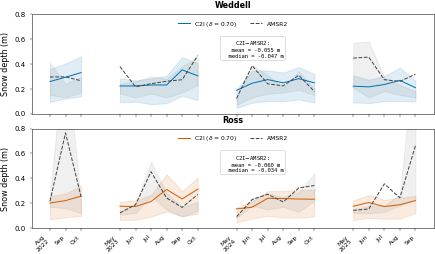

Figure 9b saved (mean snow thickness)


In [14]:
# ─── Build monthly statistics ────────────────────────────────────
winter_yms = sorted(dc.year_month.unique())

rows = []
for ym in winter_yms:
    row = {'ym': ym}
    for sec in ['Weddell', 'Ross']:
        mask = (dc.year_month == ym) & (dc.sector == sec)
        sub = dc[mask]
        n = len(sub)
        row[f'{sec}_n'] = n
        if n > 0:
            row[f'{sec}_c2i_med']  = sub.snow_thickness.median()
            row[f'{sec}_c2i_mean'] = sub.snow_thickness.mean()
            row[f'{sec}_c2i_q25']  = sub.snow_thickness.quantile(0.25)
            row[f'{sec}_c2i_q75']  = sub.snow_thickness.quantile(0.75)
            row[f'{sec}_amsr_med'] = sub.AMSR2_snow_depth.median()
            row[f'{sec}_amsr_mean']= sub.AMSR2_snow_depth.mean()
            row[f'{sec}_amsr_q25'] = sub.AMSR2_snow_depth.quantile(0.25)
            row[f'{sec}_amsr_q75'] = sub.AMSR2_snow_depth.quantile(0.75)
            row[f'{sec}_diff_med'] = sub.bias.median()
            row[f'{sec}_diff_mean']= sub.bias.mean()
        else:
            for k in ['c2i_med','c2i_mean','c2i_q25','c2i_q75',
                       'amsr_med','amsr_mean','amsr_q25','amsr_q75',
                       'diff_med','diff_mean']:
                row[f'{sec}_{k}'] = np.nan
    rows.append(row)
ms = pd.DataFrame(rows)

# ─── Print monthly differences ───────────────────────────────────
print('POOLED BY CALENDAR MONTH (mean / median):')
_mn = {5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct'}
for mn in [5,6,7,8,9,10]:
    for sec in ['Weddell', 'Ross']:
        mask = (dc.month == mn) & (dc.sector == sec)
        sub = dc[mask]
        if len(sub) > 0:
            print(f'  {_mn[mn]:>3} {sec:>8}: '
                  f'C2I mean={sub.snow_thickness.mean():.3f} (med={sub.snow_thickness.median():.3f})  '
                  f'AMSR2 mean={sub.AMSR2_snow_depth.mean():.3f} (med={sub.AMSR2_snow_depth.median():.3f})  '
                  f'diff mean={sub.bias.mean():+.3f} (med={sub.bias.median():+.3f})')

# ─── Year breaks for x-axis gaps ────────────────────────────────
year_breaks = []
for i in range(len(winter_yms) - 1):
    m1 = int(str(winter_yms[i])[4:6])
    m2 = int(str(winter_yms[i+1])[4:6])
    if m1 == 10 and m2 == 5:
        year_breaks.append(i)

x_pos = np.zeros(len(winter_yms))
gap = 1.5
offset = 0
for i in range(len(winter_yms)):
    x_pos[i] = i + offset
    if i in year_breaks:
        offset += gap

# ─── Identify first month of each winter season ─────────────────
first_of_season = set()
first_of_season.add(0)  # first month is always labelled with year
for brk in year_breaks:
    first_of_season.add(brk + 1)

# ─── Plot ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(183/25.4, 100/25.4),
                         sharex=True)
fig.subplots_adjust(hspace=0.15)

for ax, sec, color in [
    (axes[0], 'Weddell', C_WEDDELL),
    (axes[1], 'Ross', C_ROSS),
]:
    c2i_med  = ms[f'{sec}_c2i_mean'].values  # Changed: plot MEAN
    c2i_q25  = ms[f'{sec}_c2i_q25'].values
    c2i_q75  = ms[f'{sec}_c2i_q75'].values
    amsr_med = ms[f'{sec}_amsr_mean'].values  # Changed: plot MEAN
    amsr_q25 = ms[f'{sec}_amsr_q25'].values
    amsr_q75 = ms[f'{sec}_amsr_q75'].values
    n_vals   = ms[f'{sec}_n'].values

    seg_start = 0
    first_c2i = True
    first_amsr = True
    for brk in year_breaks + [len(winter_yms) - 1]:
        seg = slice(seg_start, brk + 1)
        v = np.isfinite(c2i_med[seg]) & (n_vals[seg] > 0)
        if v.any():
            lbl_c = r'C2I ($\delta$ = 0.70)' if first_c2i else None
            ax.plot(x_pos[seg][v], c2i_med[seg][v], '-', color=color,
                    lw=1.0, label=lbl_c)
            ax.fill_between(x_pos[seg][v], c2i_q25[seg][v],
                            c2i_q75[seg][v], color=color, alpha=0.12)
            first_c2i = False

            lbl_a = 'AMSR2' if first_amsr else None
            ax.plot(x_pos[seg][v], amsr_med[seg][v], '--',
                    color=C_AMSR2, lw=1.0, label=lbl_a)
            ax.fill_between(x_pos[seg][v], amsr_q25[seg][v],
                            amsr_q75[seg][v], color=C_AMSR2, alpha=0.08)
            first_amsr = False
        seg_start = brk + 1

    ax.set_ylabel('Snow depth (m)')
    ax.set_ylim(0, 0.80)
    ax.set_title(sec, fontsize=8)
    ax.legend(frameon=False, fontsize=6, loc='upper center', ncol=2)

    # ── Annotate both mean and median difference values ──────────
    sec_sub = dc[dc.sector == sec]
    ax.text(0.55, 0.75,
            f'C2I$-$AMSR2:\n'
            f'  mean = {sec_sub.bias.mean():+.3f} m\n'
            f'  median = {sec_sub.bias.median():+.3f} m',
            transform=ax.transAxes, fontsize=5.5, va='top', ha='center',
            family='monospace',
            bbox=dict(fc='white', alpha=0.85, ec='grey', lw=0.3,
                      boxstyle='round,pad=0.3'))

# ── X-axis labels: show year at first month of each season ───────
ax = axes[1]
ax.set_xticks(x_pos)
_mn_full = {5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct'}
labels_b = []
for idx_ym, ym in enumerate(winter_yms):
    mn = int(str(ym)[4:6])
    yr = str(ym)[:4]
    if idx_ym in first_of_season:
        labels_b.append(f'{_mn_full[mn]}\n{yr}')
    else:
        labels_b.append(_mn_full[mn])
ax.set_xticklabels(labels_b, fontsize=6, rotation=45, ha='right')
ax.set_xlabel('')

plt.savefig(f'{FIG_DIR}/fig09b_amsr2_monthly_timeseries.pdf')
plt.savefig(f'{FIG_DIR}/fig09b_amsr2_monthly_timeseries.png', dpi=600)
plt.show()
print('Figure 9b saved (mean snow thickness)')


## 13.6 Figure 10: PDF Comparison (fixed visibility + mean/median)

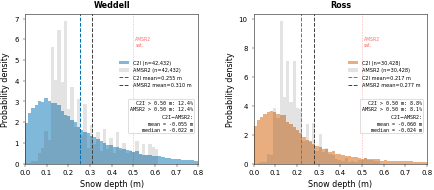

Figure 10 saved


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(183/25.4, 70/25.4))
fig.subplots_adjust(wspace=0.32)

bins = np.arange(0, 0.82, 0.015)

for ax, sec, color in [
    (axes[0], 'Weddell', C_WEDDELL),
    (axes[1], 'Ross', C_ROSS),
]:
    sub = dc[dc.sector == sec]
    c2i  = sub.snow_thickness.values
    amsr = sub.AMSR2_snow_depth.values

    # C2I histogram (filled)
    ax.hist(c2i, bins=bins, density=True, alpha=0.50, color=color,
            edgecolor='none', label=f'C2I (n={len(c2i):,})')

    # AMSR2 histogram — filled + bold step outline
    ax.hist(amsr, bins=bins, density=True, alpha=0.15,
            color=C_AMSR2, edgecolor='none',
            label=f'AMSR2 (n={len(amsr):,})')
    ax.hist(amsr, bins=bins, density=True, alpha=0.0,
            color=C_AMSR2,
            edgecolor=C_AMSR2, linewidth=1.5, histtype='step',
            label=None)

    # Median + mean lines
    c2i_med, c2i_mean = np.median(c2i), np.mean(c2i)
    amsr_med, amsr_mean = np.median(amsr), np.mean(amsr)
    ax.axvline(c2i_mean, color=color, ls='--', lw=1.0,
               label=f'C2I mean={c2i_mean:.3f} m')
    ax.axvline(amsr_mean, color=C_AMSR2, ls='--', lw=1.0,
               label=f'AMSR2 mean={amsr_mean:.3f} m')

    # AMSR2 saturation threshold
    ax.axvline(0.50, color='red', ls=':', lw=0.6, alpha=0.5)
    ax.text(0.51, 0.85, 'AMSR2\nsat.',
            fontsize=4.5, color='red', alpha=0.6,
            va='top', transform=ax.get_xaxis_transform())

    # Annotation box — both mean and median
    frac_c2i_above = 100 * np.sum(c2i > 0.50) / len(c2i)
    frac_amsr_above = 100 * np.sum(amsr > 0.50) / len(amsr)

    ax.text(0.97, 0.42,
            f'C2I > 0.50 m: {frac_c2i_above:.1f}%\n'
            f'AMSR2 > 0.50 m: {frac_amsr_above:.1f}%\n'
            f'C2I$-$AMSR2:\n'
            f'  mean = {c2i_mean - amsr_mean:+.3f} m\n'
            f'  median = {c2i_med - amsr_med:+.3f} m',
            transform=ax.transAxes, fontsize=5, va='top', ha='right',
            family='monospace',
            bbox=dict(fc='white', alpha=0.85, ec='grey', lw=0.3,
                      boxstyle='round,pad=0.3'))

    ax.set_xlabel('Snow depth (m)')
    ax.set_ylabel('Probability density')
    ax.set_title(sec, fontsize=8)
    ax.set_xlim(0, 0.80)
    ax.legend(frameon=False, fontsize=5, loc='upper right',
              bbox_to_anchor=(0.99, 0.72))

plt.savefig(f'{FIG_DIR}/fig10_amsr2_pdf_comparison.pdf')
plt.savefig(f'{FIG_DIR}/fig10_amsr2_pdf_comparison.png', dpi=600)
plt.show()
print('Figure 10 saved')


## 13.7 Summary Statistics

In [7]:
print('=' * 75)
print('AMSR2 COMPARISON SUMMARY (mean / median)')
print('=' * 75)

for sec in ['Weddell', 'Ross']:
    sub = dc[dc.sector == sec]
    print(f'\n{sec} (n = {len(sub):,}):')
    print(f'  C2I:   mean = {sub.snow_thickness.mean():.3f}, median = {sub.snow_thickness.median():.3f} m')
    print(f'  AMSR2: mean = {sub.AMSR2_snow_depth.mean():.3f}, median = {sub.AMSR2_snow_depth.median():.3f} m')
    print(f'  Diff:  mean = {sub.bias.mean():+.3f}, median = {sub.bias.median():+.3f} m')
    print(f'  RMSD:  {np.sqrt(np.mean(sub.bias.values**2)):.3f} m')
    r, p = pearsonr(sub.snow_thickness.values, sub.AMSR2_snow_depth.values)
    print(f'  r = {r:.3f}, p = {p:.2e}')
    print(f'  C2I > 0.50 m:   {100*np.sum(sub.snow_thickness > 0.50)/len(sub):.1f}%')
    print(f'  AMSR2 > 0.50 m: {100*np.sum(sub.AMSR2_snow_depth > 0.50)/len(sub):.1f}%')


AMSR2 COMPARISON SUMMARY (mean / median)

Weddell (n = 42,432):
  C2I:   mean = 0.255, median = 0.188 m
  AMSR2: mean = 0.310, median = 0.210 m
  Diff:  mean = -0.055, median = -0.047 m
  RMSD:  0.359 m
  r = 0.103, p = 7.83e-101
  C2I > 0.50 m:   12.4%
  AMSR2 > 0.50 m: 12.4%

Ross (n = 30,428):
  C2I:   mean = 0.217, median = 0.156 m
  AMSR2: mean = 0.277, median = 0.180 m
  Diff:  mean = -0.060, median = -0.034 m
  RMSD:  0.390 m
  r = 0.019, p = 7.62e-04
  C2I > 0.50 m:   8.8%
  AMSR2 > 0.50 m: 8.1%


## 13.8 Save Outputs

In [8]:
import xarray as xr

x_coords = np.linspace(area_def.area_extent[0], area_def.area_extent[2], nx)
y_coords = np.linspace(area_def.area_extent[1], area_def.area_extent[3], ny)

ds = xr.Dataset({
    'c2i_snow_median':  (['y', 'x'], grid_c2i_med),
    'amsr2_snow_median': (['y', 'x'], grid_amsr_med),
    'difference_median': (['y', 'x'], grid_diff_med),
    'count':             (['y', 'x'], grid_count),
}, coords={'x': x_coords, 'y': y_coords})
ds.attrs['description'] = 'CRYO2ICE vs AMSR2 gridded comparison 25km, winter 2022-2025, delta=0.70'

outfile = f'{HS_DIR}/amsr2_comparison_gridded_25km.nc'
ds.to_netcdf(outfile)
print(f'Saved: {outfile}')

import glob
figs = sorted(glob.glob(f'{FIG_DIR}/fig09*.png') + glob.glob(f'{FIG_DIR}/fig10*.png'))
print(f'\nFigures saved ({len(figs)}):')
for f in figs:
    print(f'  {os.path.basename(f):45s} ({os.path.getsize(f)/1024:.0f} KB)')


Saved: /g/data/gv90/xl1657/phd/M2_workspace/output/snow_thickness/amsr2_comparison_gridded_25km.nc

Figures saved (4):
  fig09_amsr2_6panel_maps.png                   (1147 KB)
  fig09a_amsr2_difference_map.png               (671 KB)
  fig09b_amsr2_monthly_timeseries.png           (509 KB)
  fig10_amsr2_pdf_comparison.png                (190 KB)
